In [1]:
import random

# Predefined list of common English first names
first_names = [
    "James", "John", "Robert", "Michael", "William", "David", "Richard", "Joseph", 
    "Charles", "Thomas", "Christopher", "Daniel", "Matthew", "Anthony", "Mark", 
    "Donald", "Paul", "George", "Kenneth", "Steven", "Edward", "Brian", "Ronald", 
    "Kevin", "Jason", "Jeffrey", "Ryan", "Gary", "Nicholas", "Eric", "Jacob", "Larry"
]

def generate_name():
    # Randomly select a name from the list
    return random.choice(first_names)

# Generate and print a random English first name
print("Generated Name:", generate_name())


Generated Name: Jeffrey


In [2]:
import random

# Predefined lists for generating business names
adjectives = [
    "Bright", "Swift", "Creative", "Bold", "Innovative", "Reliable", "Global", 
    "Dynamic", "Elite", "Prime", "Pro", "Next", "Vivid", "Modern", "Trust", 
    "True", "Advanced", "Urban", "Green", "Perfect", "Secure"
]

nouns = [
    "Solutions", "Systems", "Technologies", "Enterprises", "Concepts", 
    "Partners", "Ventures", "Designs", "Group", "Innovations", "Labs", 
    "Consulting", "Network", "Services", "Strategies", "Works", "Concept", 
    "Dynamics", "Associates", "Studios", "Productions"
]

suffixes = [
    "Inc", "Ltd", "LLC", "Co", "Group", "Corp", "Enterprises", "Corporation", 
    "Technologies", "Solutions"
]

def generate_business_name():
    # Randomly select an adjective, a noun, and a suffix
    adjective = random.choice(adjectives)
    noun = random.choice(nouns)
    suffix = random.choice(suffixes)
    
    # Combine them to create a business name
    return f"{adjective} {noun} {suffix}"

# Generate and print a random business name
print("Generated Business Name:", generate_business_name())


Generated Business Name: Next Group Co


In [3]:
import random

# Example dataset of names
first_names = [
    "James", "John", "Robert", "Michael", "William", "David", "Richard", "Joseph", 
    "Charles", "Thomas", "Christopher", "Daniel", "Matthew", "Anthony", "Mark", 
    "Donald", "Paul", "George", "Kenneth", "Steven", "Edward", "Brian", "Ronald", 
    "Kevin", "Jason", "Jeffrey", "Ryan", "Gary", "Nicholas", "Eric", "Jacob", "Larry"
]

# Function to generate a random social network of people
def generate_social_network(num_people=10):
    # Randomly select `num_people` from the list
    people = random.sample(first_names, num_people)
    
    # Create a dictionary to hold the relationships
    network = {person: set() for person in people}
    
    # Randomly create connections (they know each other) between people
    for person in people:
        # Randomly decide how many people this person knows (excluding themselves)
        knows_count = random.randint(1, num_people - 1)
        knows_people = random.sample([p for p in people if p != person], knows_count)
        network[person] = set(knows_people)
    
    return network

# Function to check if two people know each other
def know_each_other(network, person1, person2):
    if person1 in network and person2 in network:
        return person2 in network[person1] or person1 in network[person2]
    return False

# Example usage:
network = generate_social_network(10)  # Create a network of 10 people
print("Generated Social Network:", network)

# Check if two people know each other
person1 = "James"
person2 = "John"
print(f"Do {person1} and {person2} know each other? {know_each_other(network, person1, person2)}")



Generated Social Network: {'Jacob': {'Michael', 'Anthony', 'Nicholas', 'James', 'Edward', 'Brian', 'Jason', 'Steven'}, 'Michael': {'Anthony', 'Jacob', 'James', 'Nicholas', 'Edward', 'Brian', 'Jason', 'William', 'Steven'}, 'William': {'Michael', 'Anthony', 'Jacob', 'Nicholas', 'James', 'Edward', 'Brian', 'Jason', 'Steven'}, 'Jason': {'Michael', 'Jacob', 'Edward', 'Brian', 'William', 'Steven'}, 'Anthony': {'Jason', 'Jacob'}, 'Edward': {'Jason', 'James', 'Steven', 'William'}, 'James': {'Anthony', 'Nicholas', 'Brian', 'Jason', 'William'}, 'Nicholas': {'Michael', 'Jacob', 'James', 'Brian', 'Jason', 'William'}, 'Brian': {'James', 'Michael', 'Steven', 'William'}, 'Steven': {'Jacob', 'William', 'Nicholas', 'James'}}
Do James and John know each other? False


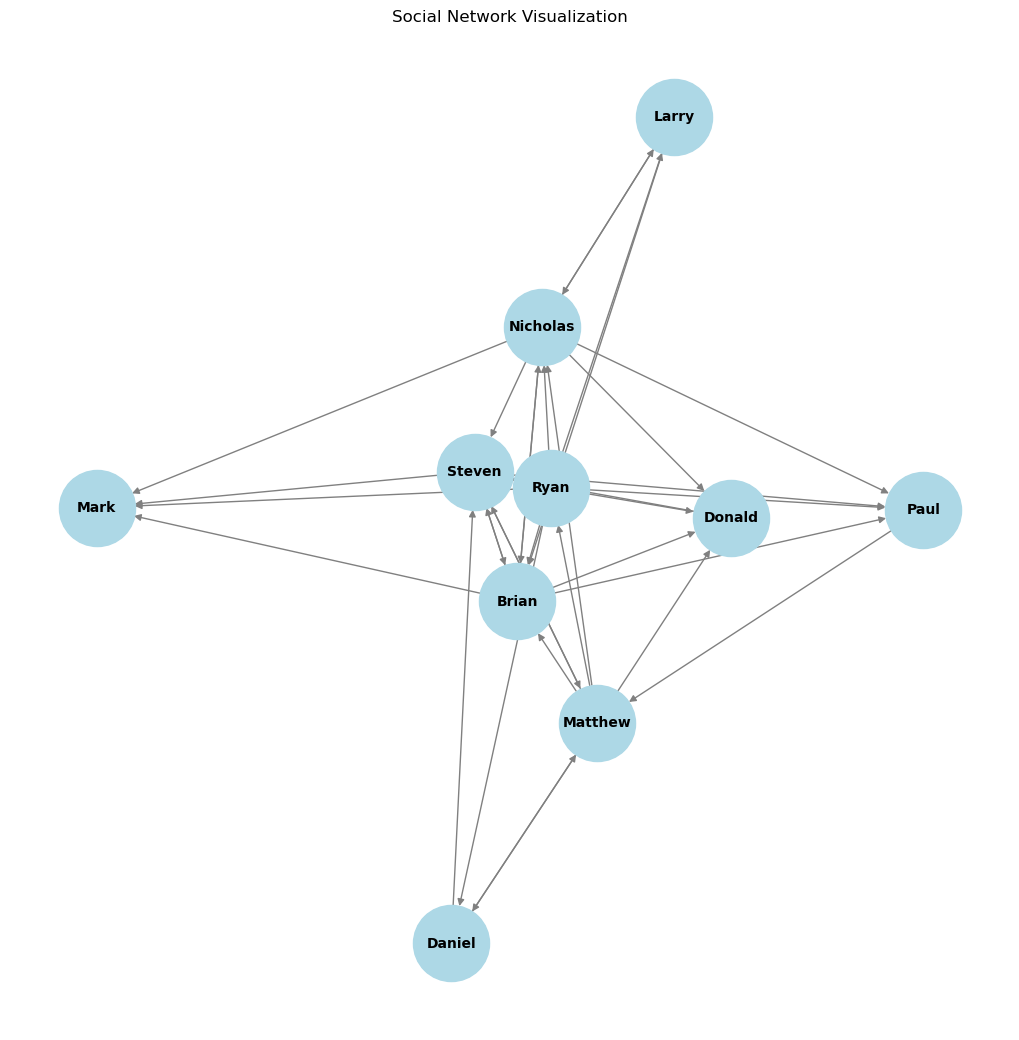

In [24]:
import random
import json
import networkx as nx
import matplotlib.pyplot as plt
import math

# Example dataset of people (can use the same list from before)
first_names = [
    "James", "John", "Robert", "Michael", "William", "David", "Richard", "Joseph", 
    "Charles", "Thomas", "Christopher", "Daniel", "Matthew", "Anthony", "Mark", 
    "Donald", "Paul", "George", "Kenneth", "Steven", "Edward", "Brian", "Ronald", 
    "Kevin", "Jason", "Jeffrey", "Ryan", "Gary", "Nicholas", "Eric", "Jacob", "Larry"
]

# Function to generate a social network and save it as a JSON file
def generate_social_network(num_people=10):
    # Randomly select `num_people` from the list
    people = random.sample(first_names, num_people)
    
    # Create a dictionary to hold the relationships
    network = {person: set() for person in people}
    
    # Randomly create connections (they know each other) between people
    for person in people:
        # Randomly decide how many people this person knows (excluding themselves)
        knows_count = random.randint(1, num_people - 1)
        knows_people = random.sample([p for p in people if p != person], knows_count)
        network[person] = set(knows_people)
    
    # Save the network as a JSON file
    with open("social_network.json", "w") as json_file:
        json.dump(list(network), json_file, indent=4)
    
    return network

# Function to create a graph from the network
def create_graph(network):
    # Create a new graph
    G = nx.DiGraph()

    # Add nodes (people)
    for person in network:
        G.add_node(person)

    # Add edges (relationships)
    for person, knows in network.items():
        for other_person in knows:
            arcdir = math.floor(random.random() * 2);
            if (arcdir == 1):
                G.add_edge(person, other_person)
            else:
                G.add_edge(other_person, person)
    
    return G

# Function to visualize the graph
def visualize_graph(G):
    # Draw the graph using matplotlib
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(G)  # positions for all nodes
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", edge_color="gray")
    plt.title("Social Network Visualization")
    plt.show()

# Example usage:
network = generate_social_network(10)  # Generate a network of 10 people

# Create and visualize the graph from the network
G = create_graph(network)
visualize_graph(G)



In [13]:
def dump_networkx_to_json(G, filepath):
    """
    Dumps a NetworkX graph to a JSON file.

    Args:
        G (networkx.Graph): The NetworkX graph to dump.
        filepath (str): The path to the JSON file to create.
    """

    data = nx.node_link_data(G)
    with open(filepath, 'w') as f:
        json.dump(data, f, indent=4)

In [30]:
import random
import json

# Example dataset of people (can use the same list from before)
people = [
    "James", "John", "Robert", "Michael", "William", "David", "Richard", "Joseph", 
    "Charles", "Thomas", "Christopher", "Daniel", "Matthew", "Anthony", "Mark", 
    "Donald", "Paul", "George", "Kenneth", "Steven", "Edward", "Brian", "Ronald", 
    "Kevin", "Jason", "Jeffrey", "Ryan", "Gary", "Nicholas", "Eric", "Jacob", "Larry"
]

# Sample list of company names
companies = [
    "Tech Solutions Inc.", "Green Enterprises", "Innovative Systems", "NextGen Labs", 
    "Elite Partners", "Global Technologies", "Smart Designs", "Dynamic Solutions", 
    "Prime Consulting", "Modern Ventures"
]

# Function to generate the works-for dataset
def generate_works_for_dataset(num_people=20):
    # Randomly select `num_people` from the list
    selected_people = random.sample(people, num_people)
    
    # Create a dictionary to hold which person works for which company
    works_for = {}
    
    for person in selected_people:
        # Randomly assign a company to this person
        company = random.choice(companies)
        works_for[person] = company
    
    # Return as a JSON object
    return json.dumps(works_for, indent=4)

# Example usage:
works_for_json = generate_works_for_dataset(20)  # Generate works-for dataset for 10 people
print(works_for_json)
with open("work_locations.json", 'w') as f:
    json.dump(works_for_json, f, indent=4)

{
    "George": "Elite Partners",
    "Jeffrey": "Modern Ventures",
    "Michael": "Global Technologies",
    "Jason": "Elite Partners",
    "William": "Modern Ventures",
    "Thomas": "Global Technologies",
    "Daniel": "Tech Solutions Inc.",
    "Robert": "Innovative Systems",
    "Larry": "Elite Partners",
    "Jacob": "Dynamic Solutions",
    "Charles": "Elite Partners",
    "Mark": "Prime Consulting",
    "Anthony": "Elite Partners",
    "Christopher": "Prime Consulting",
    "Steven": "Tech Solutions Inc.",
    "Eric": "Smart Designs",
    "Nicholas": "Modern Ventures",
    "David": "Dynamic Solutions",
    "Brian": "Global Technologies",
    "James": "Green Enterprises"
}
